In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
import itertools
import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

sns.set(style="whitegrid", context="talk")

try:
    import scikit_posthocs as sp
    HAS_POSTHOCS = True
except ImportError:
    HAS_POSTHOCS = False
    print("Warning: scikit-posthocs is not installed. Dunn post hoc tests will be skipped.")

In [14]:
DATA_DIR = Path("../../results/processed_hrv")
INPUT_FILE = DATA_DIR / "basal_v2_clean_with_categories.csv"

FIG_DIR = Path("../../results/nonparametric_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../../results/nonparametric_tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
df = pd.read_csv(INPUT_FILE)

print(df.shape)
df.head()

(530, 29)


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,...,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags,age_group,bmi_cat,bp_cat
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,...,80.213904,False,False,False,0,0,0,70-79,normal,normal
1,1,66,52.0,149.0,1.49,23.422368,122,72,88.666667,50,...,62.959077,False,False,False,0,0,0,60-69,normal,normal
2,2,77,81.0,170.0,1.70,28.027682,125,85,98.333333,40,...,68.415051,False,False,False,0,0,0,70-79,overweight,normal
3,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,...,73.260073,False,False,False,0,0,0,70-79,obesity,normal
4,1,73,69.0,151.0,1.51,30.261831,130,80,96.666667,50,...,70.921986,False,False,False,0,0,0,70-79,overweight,normal


In [16]:
hrv_cols = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

cat_cols = [
    "sex",
    "age_group",
    "bmi_cat",
    "bp_cat",
]

existing_hrv_cols = [c for c in hrv_cols if c in df.columns]
existing_cat_cols = [c for c in cat_cols if c in df.columns]

existing_hrv_cols, existing_cat_cols

(['t2m_pre_mean_rr',
  't2m_pre_mean_hr',
  't2m_pre_sdnn',
  't2m_pre_rmssd',
  't2m_pre_hf',
  't2m_pre_lf',
  't2m_pre_vlf'],
 ['sex', 'age_group', 'bmi_cat', 'bp_cat'])

In [17]:
age_order = ["<60", "60-69", "70-79", "80+"]
bmi_order = ["low", "normal", "overweight", "obesity"]
bp_order = ["normal", "high"]

if "age_group" in df.columns:
    df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

if "bmi_cat" in df.columns:
    df["bmi_cat"] = pd.Categorical(df["bmi_cat"], categories=bmi_order, ordered=True)

if "bp_cat" in df.columns:
    df["bp_cat"] = pd.Categorical(df["bp_cat"], categories=bp_order, ordered=True)

In [18]:
def cliffs_delta(x, y):
    """
    Compute Cliff's delta for two independent samples.
    """
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = 0
    lt = 0

    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    delta = (gt - lt) / (len(x) * len(y))
    return delta


def cliffs_delta_magnitude(delta):
    """
    Magnitude interpretation for Cliff's delta.
    """
    if pd.isna(delta):
        return np.nan

    ad = abs(delta)

    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"


def rank_biserial_from_u(u_stat, n1, n2):
    """
    Rank-biserial correlation derived from Mann-Whitney U.
    """
    return 1 - (2 * u_stat) / (n1 * n2)


def epsilon_squared_kruskal(h_stat, n, k):
    """
    Effect size for Kruskal-Wallis.
    """
    if n <= k:
        return np.nan
    return (h_stat - k + 1) / (n - k)


def summarize_group_distribution(df_in, group_col, value_col):
    """
    Summary stats by group.
    """
    tmp = (
        df_in[[group_col, value_col]]
        .dropna()
        .groupby(group_col)[value_col]
        .agg(
            n="count",
            median="median",
            mean="mean",
            std="std",
            q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75),
            iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
            min="min",
            max="max",
        )
        .reset_index()
    )
    return tmp


def safe_mannwhitney(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()

    if len(x) < 2 or len(y) < 2:
        return None

    res = stats.mannwhitneyu(x, y, alternative="two-sided")
    return res


def safe_kruskal(groups):
    clean_groups = [pd.Series(g).dropna() for g in groups]
    clean_groups = [g for g in clean_groups if len(g) >= 2]

    if len(clean_groups) < 2:
        return None

    return stats.kruskal(*clean_groups)

In [19]:
def save_table(df_table, filename):
    out = TABLE_DIR / filename
    df_table.to_csv(out, index=False)
    return out

In [20]:
for col in existing_cat_cols:
    freq = df[col].value_counts(dropna=False).reset_index()
    freq.columns = [col, "n"]
    freq["pct"] = (freq["n"] / len(df) * 100).round(2)

    print(f"\n=== {col} ===")
    print(freq)

    save_table(freq, f"freq_{col}.csv")


=== sex ===
   sex    n    pct
0    1  366  69.06
1    2  164  30.94

=== age_group ===
  age_group    n    pct
0     70-79  261  49.25
1     60-69  219  41.32
2       80+   40   7.55
3       <60   10   1.89

=== bmi_cat ===
      bmi_cat    n    pct
0     obesity  184  34.72
1  overweight  162  30.57
2      normal  161  30.38
3         low   23   4.34

=== bp_cat ===
   bp_cat    n    pct
0  normal  369  69.62
1    high  161  30.38


In [21]:
for g in existing_cat_cols:
    for hrv in existing_hrv_cols:
        summary = summarize_group_distribution(df, g, hrv)
        save_table(summary, f"summary_{hrv}_by_{g}.csv")

In [22]:
binary_groups = []

for g in existing_cat_cols:
    n_levels = df[g].dropna().nunique()
    if n_levels == 2:
        binary_groups.append(g)

binary_groups

['sex', 'bp_cat']

In [23]:
def run_binary_comparisons(df_in, group_col, value_cols):
    levels = [x for x in df_in[group_col].dropna().unique().tolist()]
    if len(levels) != 2:
        return pd.DataFrame()

    level_a, level_b = levels[0], levels[1]

    results = []

    for value_col in value_cols:
        tmp = df_in[[group_col, value_col]].dropna()

        x = tmp.loc[tmp[group_col] == level_a, value_col]
        y = tmp.loc[tmp[group_col] == level_b, value_col]

        if len(x) < 2 or len(y) < 2:
            continue

        test = safe_mannwhitney(x, y)
        if test is None:
            continue

        delta = cliffs_delta(x, y)
        rbc = rank_biserial_from_u(test.statistic, len(x), len(y))

        results.append({
            "grouping_variable": group_col,
            "value_variable": value_col,
            "group_a": level_a,
            "group_b": level_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.median(x),
            "median_b": np.median(y),
            "u_stat": test.statistic,
            "p_value": test.pvalue,
            "cliffs_delta": delta,
            "cliffs_magnitude": cliffs_delta_magnitude(delta),
            "rank_biserial": rbc,
        })

    res_df = pd.DataFrame(results)

    if not res_df.empty:
        reject, p_adj, _, _ = multipletests(res_df["p_value"], method="fdr_bh")
        res_df["p_adj_fdr"] = p_adj
        res_df["significant_fdr"] = reject

    return res_df

In [24]:
binary_results_all = []

for g in binary_groups:
    res = run_binary_comparisons(df, g, existing_hrv_cols)
    if not res.empty:
        binary_results_all.append(res)

binary_results_df = pd.concat(binary_results_all, ignore_index=True) if binary_results_all else pd.DataFrame()
binary_results_df

,grouping_variable,value_variable,group_a,group_b,n_a,n_b,median_a,median_b,u_stat,p_value,cliffs_delta,cliffs_magnitude,rank_biserial,p_adj_fdr,significant_fdr
0,sex,t2m_pre_mean_rr,1,2,366,164,848.5,857.00,29540.0,7.723418e-01,-0.015727,negligible,0.015727,9.010655e-01,False
1,sex,t2m_pre_mean_hr,1,2,366,163,70.0,69.00,29993.5,9.194842e-01,0.005515,negligible,-0.005515,9.194842e-01,False
2,sex,t2m_pre_sdnn,1,2,360,159,154.0,72.00,40023.5,4.472665e-13,0.398445,medium,-0.398445,3.130865e-12,True
3,sex,t2m_pre_rmssd,1,2,362,160,14.0,12.50,33108.5,9.032589e-03,0.143249,negligible,-0.143249,1.746491e-02,True
4,sex,t2m_pre_hf,1,2,366,164,111.0,76.00,32787.5,8.861350e-02,0.092480,negligible,-0.092480,1.240589e-01,False
5,sex,t2m_pre_lf,1,2,366,164,129.0,98.50,34211.5,9.979947e-03,0.139927,negligible,-0.139927,1.746491e-02,True
6,sex,t2m_pre_vlf,1,2,366,164,35.0,25.00,36530.5,6.335911e-05,0.217196,small,-0.217196,2.217569e-04,True
7,bp_cat,t2m_pre_mean_rr,normal,high,369,161,857.0,834.00,32313.0,1.077183e-01,0.087815,negligible,-0.087815,3.770140e-01,False
8,bp_cat,t2m_pre_mean_hr,normal,high,368,161,69.5,72.00,27020.5,1.074122e-01,-0.087885,negligible,0.087885,3.770140e-01,False
9,bp_cat,t2m_pre_sdnn,normal,high,361,158,140.0,134.50,29169.0,6.795077e-01,0.022792,negligible,-0.022792,7.610749e-01,False


In [25]:
if not binary_results_df.empty:
    save_table(binary_results_df, "binary_group_comparisons_mannwhitney_cliff.csv")

In [26]:
multigroup_vars = []

for g in existing_cat_cols:
    n_levels = df[g].dropna().nunique()
    if n_levels >= 3:
        multigroup_vars.append(g)

multigroup_vars

['age_group', 'bmi_cat']

In [27]:
def run_kruskal_by_group(df_in, group_col, value_cols):
    results = []

    valid_levels = [lvl for lvl in df_in[group_col].dropna().unique().tolist()]

    for value_col in value_cols:
        tmp = df_in[[group_col, value_col]].dropna()

        groups = []
        sizes = {}

        for lvl in valid_levels:
            vec = tmp.loc[tmp[group_col] == lvl, value_col]
            if len(vec) >= 2:
                groups.append(vec)
                sizes[str(lvl)] = int(len(vec))

        if len(groups) < 2:
            continue

        test = safe_kruskal(groups)
        if test is None:
            continue

        n_total = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = epsilon_squared_kruskal(test.statistic, n_total, k)

        results.append({
            "grouping_variable": group_col,
            "value_variable": value_col,
            "n_total": n_total,
            "n_groups": k,
            "h_stat": test.statistic,
            "p_value": test.pvalue,
            "epsilon_squared": eps2,
            "group_sizes": sizes,
        })

    res_df = pd.DataFrame(results)

    if not res_df.empty:
        reject, p_adj, _, _ = multipletests(res_df["p_value"], method="fdr_bh")
        res_df["p_adj_fdr"] = p_adj
        res_df["significant_fdr"] = reject

    return res_df

In [28]:
kruskal_results_all = []

for g in multigroup_vars:
    res = run_kruskal_by_group(df, g, existing_hrv_cols)
    if not res.empty:
        kruskal_results_all.append(res)

kruskal_results_df = pd.concat(kruskal_results_all, ignore_index=True) if kruskal_results_all else pd.DataFrame()
kruskal_results_df

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr
0,age_group,t2m_pre_mean_rr,530,4,5.220645,0.156335,0.004222,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.182391,False
1,age_group,t2m_pre_mean_hr,529,4,8.089549,0.044197,0.009694,"{'70-79': 261, '60-69': 218, '80+': 40, '<60':...",0.103126,False
2,age_group,t2m_pre_sdnn,519,4,5.520829,0.137398,0.004895,"{'70-79': 256, '60-69': 214, '80+': 39, '<60':...",0.182391,False
3,age_group,t2m_pre_rmssd,522,4,4.480695,0.214019,0.002858,"{'70-79': 255, '60-69': 217, '80+': 40, '<60':...",0.214019,False
4,age_group,t2m_pre_hf,530,4,11.828574,0.007994,0.016784,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.027979,True
5,age_group,t2m_pre_lf,530,4,19.444978,0.000221,0.031264,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.001548,True
6,age_group,t2m_pre_vlf,530,4,7.265084,0.063912,0.008109,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.111846,False
7,bmi_cat,t2m_pre_mean_rr,530,4,5.056120,0.167734,0.003909,"{'normal': 161, 'overweight': 162, 'obesity': ...",0.533046,False
8,bmi_cat,t2m_pre_mean_hr,529,4,1.877580,0.598200,-0.002138,"{'normal': 160, 'overweight': 162, 'obesity': ...",0.697900,False
9,bmi_cat,t2m_pre_sdnn,519,4,7.261466,0.064015,0.008275,"{'normal': 153, 'overweight': 160, 'obesity': ...",0.448104,False


In [29]:
if not kruskal_results_df.empty:
    save_table(kruskal_results_df, "multigroup_kruskal_results.csv")

In [30]:
def run_dunn_posthoc(df_in, group_col, value_col, p_adjust="fdr_bh"):
    if not HAS_POSTHOCS:
        return pd.DataFrame()

    tmp = df_in[[group_col, value_col]].dropna().copy()

    if tmp[group_col].nunique() < 3:
        return pd.DataFrame()

    dunn = sp.posthoc_dunn(
        tmp,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust
    )

    dunn_long = (
        dunn.stack()
        .reset_index()
    )
    dunn_long.columns = ["group_a", "group_b", "p_adj"]

    dunn_long = dunn_long[dunn_long["group_a"] != dunn_long["group_b"]].copy()

    # remove duplicated pair direction
    dunn_long["pair_key"] = dunn_long.apply(
        lambda r: " vs ".join(sorted([str(r["group_a"]), str(r["group_b"])])),
        axis=1
    )
    dunn_long = dunn_long.drop_duplicates("pair_key").drop(columns="pair_key")

    dunn_long["grouping_variable"] = group_col
    dunn_long["value_variable"] = value_col

    return dunn_long[["grouping_variable", "value_variable", "group_a", "group_b", "p_adj"]]

In [31]:
def run_pairwise_cliff(df_in, group_col, value_col):
    tmp = df_in[[group_col, value_col]].dropna().copy()
    levels = [lvl for lvl in tmp[group_col].dropna().unique().tolist()]

    pairs = list(itertools.combinations(levels, 2))
    out = []

    for a, b in pairs:
        x = tmp.loc[tmp[group_col] == a, value_col]
        y = tmp.loc[tmp[group_col] == b, value_col]

        if len(x) < 2 or len(y) < 2:
            continue

        delta = cliffs_delta(x, y)
        mw = safe_mannwhitney(x, y)
        p_val = mw.pvalue if mw is not None else np.nan

        out.append({
            "grouping_variable": group_col,
            "value_variable": value_col,
            "group_a": a,
            "group_b": b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.median(x),
            "median_b": np.median(y),
            "p_value_raw": p_val,
            "cliffs_delta": delta,
            "cliffs_magnitude": cliffs_delta_magnitude(delta),
        })

    out_df = pd.DataFrame(out)

    if not out_df.empty:
        reject, p_adj, _, _ = multipletests(out_df["p_value_raw"], method="fdr_bh")
        out_df["p_adj_fdr"] = p_adj
        out_df["significant_fdr"] = reject

    return out_df

In [32]:
pairwise_multigroup_all = []

for g in multigroup_vars:
    for hrv in existing_hrv_cols:
        res = run_pairwise_cliff(df, g, hrv)
        if not res.empty:
            pairwise_multigroup_all.append(res)

pairwise_multigroup_df = (
    pd.concat(pairwise_multigroup_all, ignore_index=True)
    if pairwise_multigroup_all else pd.DataFrame()
)

pairwise_multigroup_df.head()

,grouping_variable,value_variable,group_a,group_b,n_a,n_b,median_a,median_b,p_value_raw,cliffs_delta,cliffs_magnitude,p_adj_fdr,significant_fdr
0,age_group,t2m_pre_mean_rr,70-79,60-69,261,219,862.0,830.0,0.067342,0.096905,negligible,0.243805,False
1,age_group,t2m_pre_mean_rr,70-79,80+,261,40,862.0,884.5,0.517802,-0.063602,negligible,0.776703,False
2,age_group,t2m_pre_mean_rr,70-79,<60,261,10,862.0,883.0,0.779801,-0.052490,negligible,0.935762,False
3,age_group,t2m_pre_mean_rr,60-69,80+,219,40,830.0,884.5,0.081268,-0.173516,small,0.243805,False
4,age_group,t2m_pre_mean_rr,60-69,<60,219,10,830.0,883.0,0.319374,-0.186758,small,0.638748,False


In [33]:
if not pairwise_multigroup_df.empty:
    save_table(pairwise_multigroup_df, "pairwise_multigroup_cliffs_delta.csv")

In [34]:
dunn_all = []

if HAS_POSTHOCS:
    for g in multigroup_vars:
        for hrv in existing_hrv_cols:
            res = run_dunn_posthoc(df, g, hrv, p_adjust="fdr_bh")
            if not res.empty:
                dunn_all.append(res)

dunn_df = pd.concat(dunn_all, ignore_index=True) if dunn_all else pd.DataFrame()
dunn_df.head()

,grouping_variable,value_variable,group_a,group_b,p_adj
0,age_group,t2m_pre_mean_rr,<60,60-69,0.728277
1,age_group,t2m_pre_mean_rr,<60,70-79,0.847953
2,age_group,t2m_pre_mean_rr,<60,80+,0.993553
3,age_group,t2m_pre_mean_rr,60-69,70-79,0.278326
4,age_group,t2m_pre_mean_rr,60-69,80+,0.278326


In [35]:
if not dunn_df.empty:
    save_table(dunn_df, "dunn_posthoc_results.csv")

In [36]:
if not binary_results_df.empty:
    display_cols = [
        "grouping_variable", "value_variable", "group_a", "group_b",
        "median_a", "median_b", "p_value", "p_adj_fdr",
        "cliffs_delta", "cliffs_magnitude"
    ]
    binary_results_df.sort_values("p_adj_fdr").head(20)[display_cols]

In [38]:
if not kruskal_results_df.empty:
    display_cols = [
        "grouping_variable", "value_variable", "h_stat",
        "p_value", "p_adj_fdr", "epsilon_squared"
    ]
    kruskal_results_df.sort_values("p_adj_fdr").head(20)[display_cols]

In [39]:
double_combinations = [
    ("sex", "age_group"),
    ("sex", "bmi_cat"),
    ("sex", "bp_cat"),
    ("age_group", "bmi_cat"),
    ("age_group", "bp_cat"),
    ("bmi_cat", "bp_cat"),
]

double_combinations = [
    comb for comb in double_combinations
    if comb[0] in df.columns and comb[1] in df.columns
]

double_combinations

[('sex', 'age_group'),
 ('sex', 'bmi_cat'),
 ('sex', 'bp_cat'),
 ('age_group', 'bmi_cat'),
 ('age_group', 'bp_cat'),
 ('bmi_cat', 'bp_cat')]

In [40]:
def make_combined_category(df_in, cols, min_n=5):
    name = "__".join(cols)
    tmp = df_in.copy()

    tmp[name] = tmp[list(cols)].astype(str).agg(" | ".join, axis=1)

    # replace rows where any source category is missing
    mask_missing = tmp[list(cols)].isna().any(axis=1)
    tmp.loc[mask_missing, name] = np.nan

    counts = tmp[name].value_counts(dropna=True)
    valid_levels = counts[counts >= min_n].index.tolist()

    tmp.loc[~tmp[name].isin(valid_levels), name] = np.nan

    return tmp, name, counts

In [41]:
for comb in double_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=5)
    print(f"\n=== {comb_name} ===")
    print(counts)
    counts.to_csv(TABLE_DIR / f"counts_{comb_name}.csv")


=== sex__age_group ===
sex__age_group
1 | 70-79    167
1 | 60-69    162
2 | 70-79     94
2 | 60-69     57
1 | 80+       29
2 | 80+       11
1 | <60        8
2 | <60        2
Name: count, dtype: int64

=== sex__bmi_cat ===
sex__bmi_cat
1 | obesity       130
1 | normal        114
1 | overweight    105
2 | overweight     57
2 | obesity        54
2 | normal         47
1 | low            17
2 | low             6
Name: count, dtype: int64

=== sex__bp_cat ===
sex__bp_cat
1 | normal    261
2 | normal    108
1 | high      105
2 | high       56
Name: count, dtype: int64

=== age_group__bmi_cat ===
age_group__bmi_cat
60-69 | obesity       91
70-79 | overweight    86
70-79 | obesity       84
70-79 | normal        76
60-69 | normal        62
60-69 | overweight    59
80+ | normal          17
70-79 | low           15
80+ | overweight      15
60-69 | low            7
80+ | obesity          7
<60 | normal           6
<60 | overweight       2
<60 | obesity          2
80+ | low              1
Name: cou

In [42]:
double_kruskal_all = []

for comb in double_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=5)

    res = run_kruskal_by_group(tmp_df, comb_name, existing_hrv_cols)
    if not res.empty:
        res["combined_grouping"] = comb_name
        double_kruskal_all.append(res)

double_kruskal_df = (
    pd.concat(double_kruskal_all, ignore_index=True)
    if double_kruskal_all else pd.DataFrame()
)

double_kruskal_df.head()

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr,combined_grouping
0,sex__age_group,t2m_pre_mean_rr,528,7,4.909612,5.554574e-01,-0.002093,"{'1 | 70-79': 167, '1 | 60-69': 162, '2 | 70-7...",5.554574e-01,False,sex__age_group
1,sex__age_group,t2m_pre_mean_hr,527,7,8.257972,2.198063e-01,0.004342,"{'1 | 70-79': 167, '1 | 60-69': 162, '2 | 70-7...",2.564407e-01,False,sex__age_group
2,sex__age_group,t2m_pre_sdnn,517,7,62.178469,1.622659e-11,0.110154,"{'1 | 70-79': 163, '1 | 60-69': 160, '2 | 70-7...",1.135862e-10,True,sex__age_group
3,sex__age_group,t2m_pre_rmssd,520,7,11.873188,6.485836e-02,0.011449,"{'1 | 70-79': 164, '1 | 60-69': 161, '2 | 70-7...",9.080170e-02,False,sex__age_group
4,sex__age_group,t2m_pre_hf,528,7,15.601076,1.606310e-02,0.018428,"{'1 | 70-79': 167, '1 | 60-69': 162, '2 | 70-7...",2.811043e-02,True,sex__age_group


In [43]:
if not double_kruskal_df.empty:
    save_table(double_kruskal_df, "double_category_kruskal_results.csv")

In [44]:
double_pairwise_all = []

for comb in double_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=5)

    for hrv in existing_hrv_cols:
        res = run_pairwise_cliff(tmp_df, comb_name, hrv)
        if not res.empty:
            res["combined_grouping"] = comb_name
            double_pairwise_all.append(res)

double_pairwise_df = (
    pd.concat(double_pairwise_all, ignore_index=True)
    if double_pairwise_all else pd.DataFrame()
)

double_pairwise_df.head()

,grouping_variable,value_variable,group_a,group_b,n_a,n_b,median_a,median_b,p_value_raw,cliffs_delta,cliffs_magnitude,p_adj_fdr,significant_fdr,combined_grouping
0,sex__age_group,t2m_pre_mean_rr,1 | 70-79,1 | 60-69,167,162,857.0,833.5,0.144545,0.093073,negligible,0.903892,False,sex__age_group
1,sex__age_group,t2m_pre_mean_rr,1 | 70-79,2 | 70-79,167,94,857.0,876.5,0.861012,-0.013123,negligible,0.903892,False,sex__age_group
2,sex__age_group,t2m_pre_mean_rr,1 | 70-79,2 | 60-69,167,57,857.0,828.0,0.251932,0.101796,negligible,0.903892,False,sex__age_group
3,sex__age_group,t2m_pre_mean_rr,1 | 70-79,1 | 80+,167,29,857.0,885.0,0.518619,-0.075367,negligible,0.903892,False,sex__age_group
4,sex__age_group,t2m_pre_mean_rr,1 | 70-79,1 | <60,167,8,857.0,848.5,0.900508,0.026946,negligible,0.903892,False,sex__age_group


In [45]:
if not double_pairwise_df.empty:
    save_table(double_pairwise_df, "double_category_pairwise_cliffs.csv")

In [46]:
double_dunn_all = []

if HAS_POSTHOCS:
    for comb in double_combinations:
        tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=5)

        for hrv in existing_hrv_cols:
            res = run_dunn_posthoc(tmp_df, comb_name, hrv, p_adjust="fdr_bh")
            if not res.empty:
                res["combined_grouping"] = comb_name
                double_dunn_all.append(res)

double_dunn_df = (
    pd.concat(double_dunn_all, ignore_index=True)
    if double_dunn_all else pd.DataFrame()
)

double_dunn_df.head()

,grouping_variable,value_variable,group_a,group_b,p_adj,combined_grouping
0,sex__age_group,t2m_pre_mean_rr,1 | 60-69,1 | 70-79,0.865084,sex__age_group
1,sex__age_group,t2m_pre_mean_rr,1 | 60-69,1 | 80+,0.865084,sex__age_group
2,sex__age_group,t2m_pre_mean_rr,1 | 60-69,1 | <60,0.968178,sex__age_group
3,sex__age_group,t2m_pre_mean_rr,1 | 60-69,2 | 60-69,0.968178,sex__age_group
4,sex__age_group,t2m_pre_mean_rr,1 | 60-69,2 | 70-79,0.865084,sex__age_group


In [47]:
if not double_dunn_df.empty:
    save_table(double_dunn_df, "double_category_dunn_results.csv")

In [48]:
triple_combinations = [
    ("sex", "age_group", "bmi_cat"),
    ("sex", "age_group", "bp_cat"),
    ("sex", "bmi_cat", "bp_cat"),
    ("age_group", "bmi_cat", "bp_cat"),
]

triple_combinations = [
    comb for comb in triple_combinations
    if all(c in df.columns for c in comb)
]

triple_combinations

[('sex', 'age_group', 'bmi_cat'),
 ('sex', 'age_group', 'bp_cat'),
 ('sex', 'bmi_cat', 'bp_cat'),
 ('age_group', 'bmi_cat', 'bp_cat')]

In [49]:
for comb in triple_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=8)
    print(f"\n=== {comb_name} ===")
    print(counts)
    counts.to_csv(TABLE_DIR / f"counts_{comb_name}.csv")


=== sex__age_group__bmi_cat ===
sex__age_group__bmi_cat
1 | 60-69 | obesity       69
1 | 70-79 | obesity       54
1 | 70-79 | overweight    51
1 | 70-79 | normal        50
1 | 60-69 | normal        48
1 | 60-69 | overweight    41
2 | 70-79 | overweight    35
2 | 70-79 | obesity       30
2 | 70-79 | normal        26
2 | 60-69 | obesity       22
2 | 60-69 | overweight    18
2 | 60-69 | normal        14
1 | 80+ | normal          12
1 | 70-79 | low           12
1 | 80+ | overweight      11
2 | 80+ | normal           5
1 | 80+ | obesity          5
1 | <60 | normal           4
1 | 60-69 | low            4
2 | 80+ | overweight       4
2 | 60-69 | low            3
2 | 70-79 | low            3
1 | <60 | overweight       2
1 | <60 | obesity          2
2 | 80+ | obesity          2
2 | <60 | normal           2
1 | 80+ | low              1
Name: count, dtype: int64

=== sex__age_group__bp_cat ===
sex__age_group__bp_cat
1 | 70-79 | normal    119
1 | 60-69 | normal    115
2 | 70-79 | normal     61
1

In [50]:
triple_kruskal_all = []

for comb in triple_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=8)

    res = run_kruskal_by_group(tmp_df, comb_name, existing_hrv_cols)
    if not res.empty:
        res["combined_grouping"] = comb_name
        triple_kruskal_all.append(res)

triple_kruskal_df = (
    pd.concat(triple_kruskal_all, ignore_index=True)
    if triple_kruskal_all else pd.DataFrame()
)

triple_kruskal_df.head()

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr,combined_grouping
0,sex__age_group__bmi_cat,t2m_pre_mean_rr,493,15,18.407508,1.888460e-01,0.009221,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",2.203203e-01,False,sex__age_group__bmi_cat
1,sex__age_group__bmi_cat,t2m_pre_mean_hr,492,15,17.046204,2.537240e-01,0.006386,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",2.537240e-01,False,sex__age_group__bmi_cat
2,sex__age_group__bmi_cat,t2m_pre_sdnn,483,15,63.596058,2.720181e-08,0.105974,"{'1 | 70-79 | normal': 47, '1 | 60-69 | normal...",1.904127e-07,True,sex__age_group__bmi_cat
3,sex__age_group__bmi_cat,t2m_pre_rmssd,485,15,22.950866,6.107393e-02,0.019044,"{'1 | 70-79 | normal': 48, '1 | 60-69 | normal...",8.550350e-02,False,sex__age_group__bmi_cat
4,sex__age_group__bmi_cat,t2m_pre_hf,493,15,24.961358,3.495079e-02,0.022932,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",6.116389e-02,False,sex__age_group__bmi_cat


In [51]:
if not triple_kruskal_df.empty:
    save_table(triple_kruskal_df, "triple_category_kruskal_results.csv")

In [52]:
triple_pairwise_all = []

for comb in triple_combinations:
    tmp_df, comb_name, counts = make_combined_category(df, comb, min_n=8)

    for hrv in existing_hrv_cols:
        res = run_pairwise_cliff(tmp_df, comb_name, hrv)
        if not res.empty:
            res["combined_grouping"] = comb_name
            triple_pairwise_all.append(res)

triple_pairwise_df = (
    pd.concat(triple_pairwise_all, ignore_index=True)
    if triple_pairwise_all else pd.DataFrame()
)

triple_pairwise_df.head()

,grouping_variable,value_variable,group_a,group_b,n_a,n_b,median_a,median_b,p_value_raw,cliffs_delta,cliffs_magnitude,p_adj_fdr,significant_fdr,combined_grouping
0,sex__age_group__bmi_cat,t2m_pre_mean_rr,1 | 70-79 | normal,1 | 60-69 | normal,50,48,878.5,845.5,0.183852,0.156250,small,0.732598,False,sex__age_group__bmi_cat
1,sex__age_group__bmi_cat,t2m_pre_mean_rr,1 | 70-79 | normal,2 | 70-79 | overweight,50,35,878.5,842.0,0.266242,0.142857,negligible,0.732598,False,sex__age_group__bmi_cat
2,sex__age_group__bmi_cat,t2m_pre_mean_rr,1 | 70-79 | normal,1 | 70-79 | obesity,50,54,878.5,848.5,0.050571,0.222963,small,0.474673,False,sex__age_group__bmi_cat
3,sex__age_group__bmi_cat,t2m_pre_mean_rr,1 | 70-79 | normal,1 | 70-79 | overweight,50,51,878.5,862.0,0.362707,0.105490,negligible,0.746751,False,sex__age_group__bmi_cat
4,sex__age_group__bmi_cat,t2m_pre_mean_rr,1 | 70-79 | normal,1 | 60-69 | overweight,50,41,878.5,786.0,0.002706,0.367317,medium,0.284165,False,sex__age_group__bmi_cat


In [53]:
if not triple_pairwise_df.empty:
    save_table(triple_pairwise_df, "triple_category_pairwise_cliffs.csv")

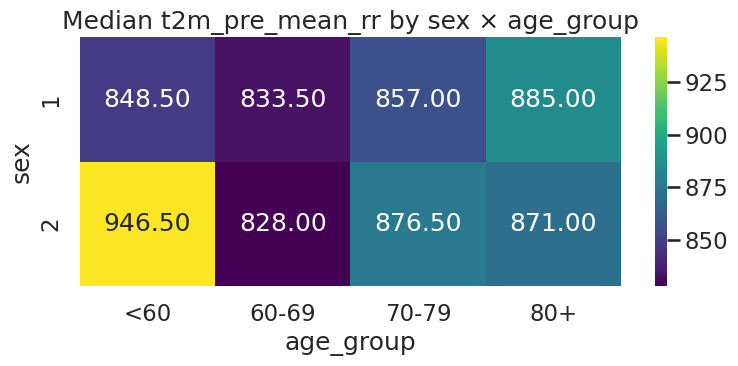

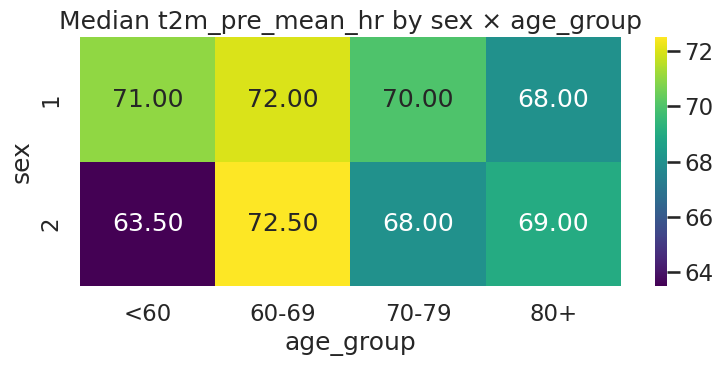

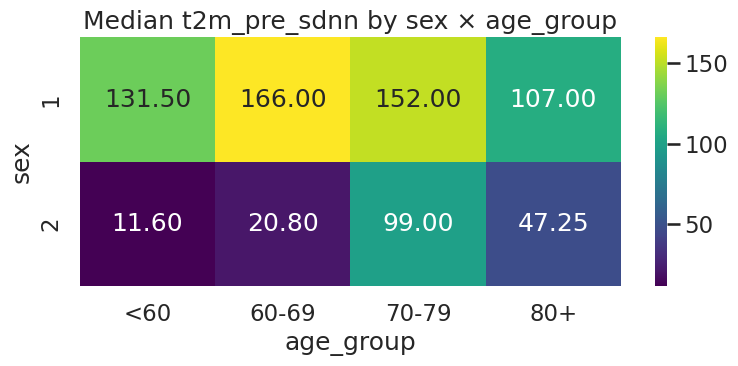

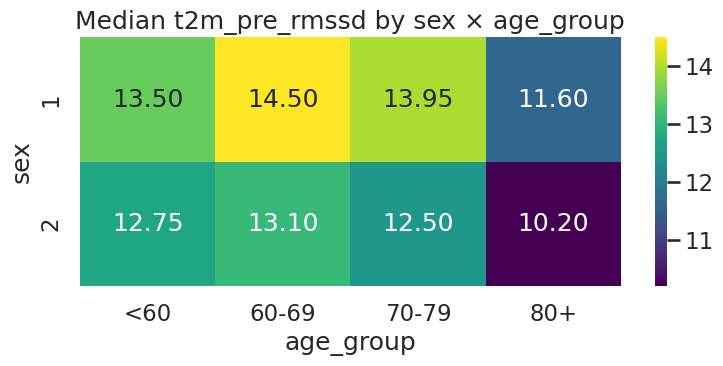

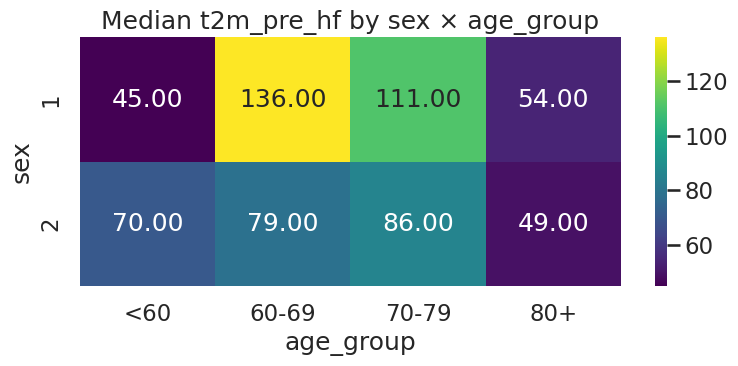

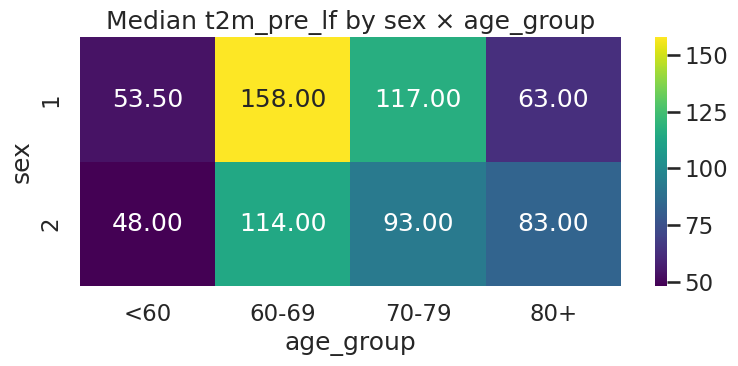

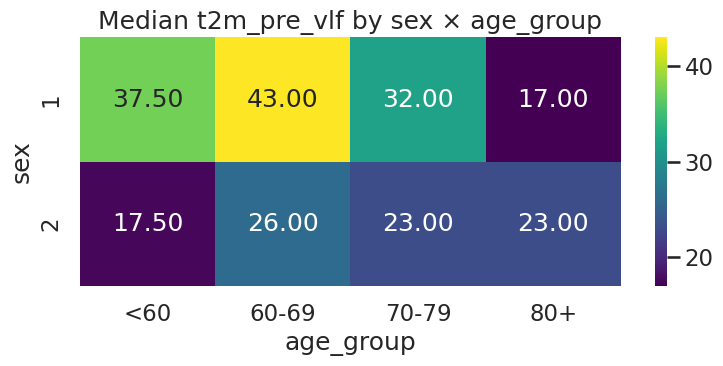

In [54]:
if all(c in df.columns for c in ["sex", "age_group"]):
    for hrv in existing_hrv_cols:
        tab = df.pivot_table(
            index="sex",
            columns="age_group",
            values=hrv,
            aggfunc="median"
        )

        plt.figure(figsize=(8, 4))
        sns.heatmap(tab, annot=True, fmt=".2f", cmap="viridis")
        plt.title(f"Median {hrv} by sex × age_group")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"heatmap_{hrv}_sex_age_group.png", dpi=300)
        plt.show()

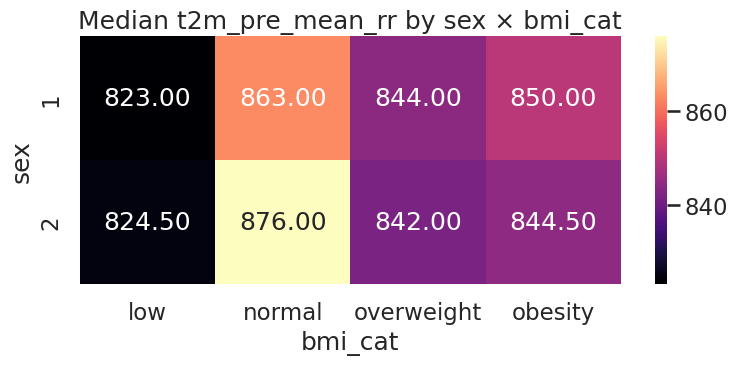

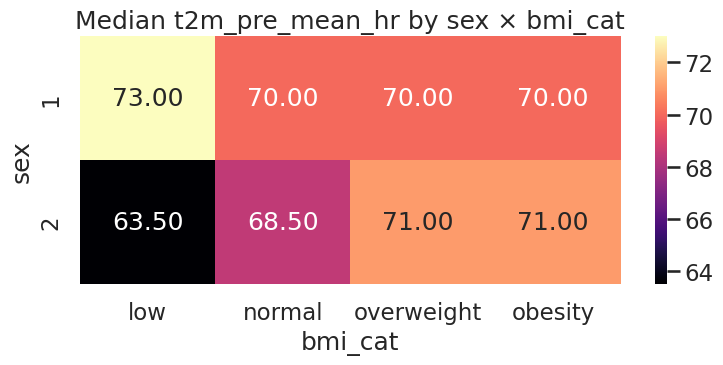

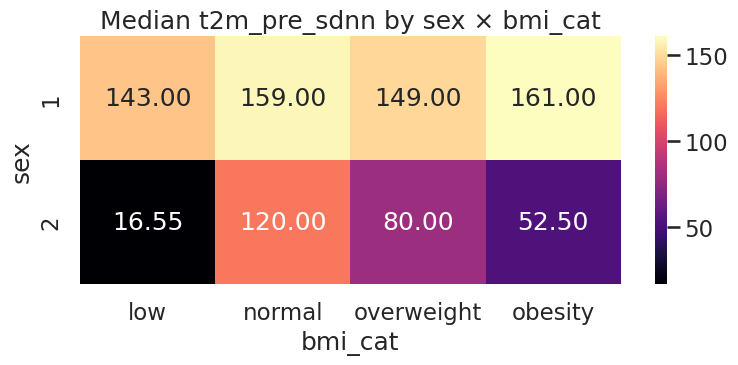

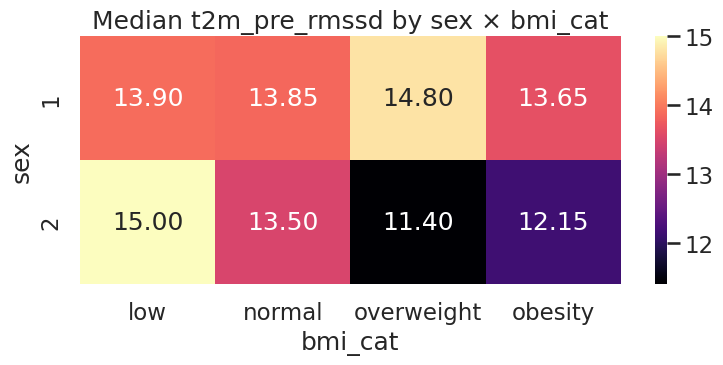

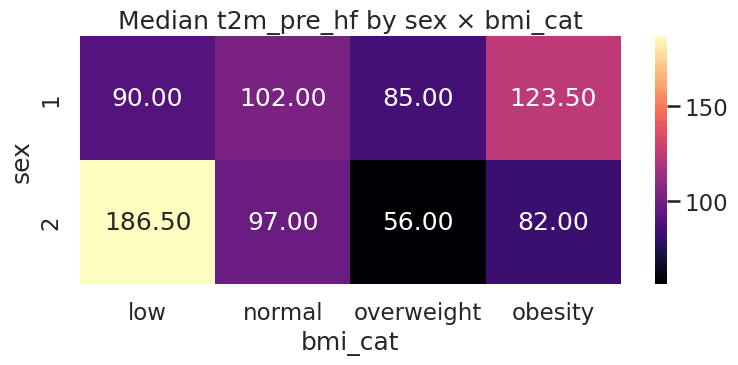

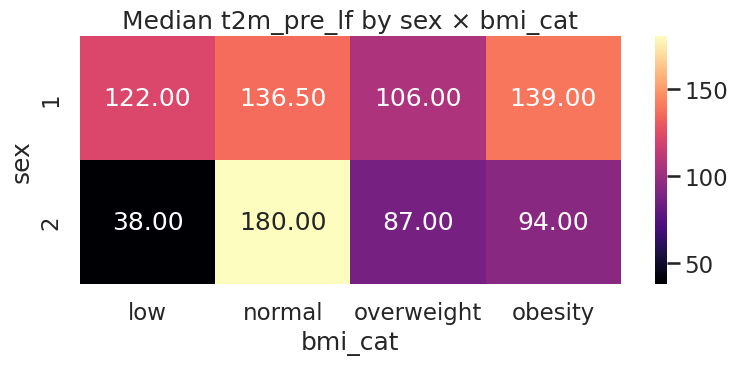

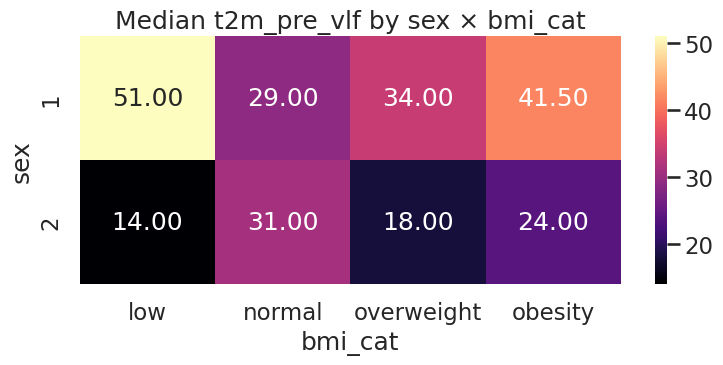

In [55]:
if all(c in df.columns for c in ["sex", "bmi_cat"]):
    for hrv in existing_hrv_cols:
        tab = df.pivot_table(
            index="sex",
            columns="bmi_cat",
            values=hrv,
            aggfunc="median"
        )

        plt.figure(figsize=(8, 4))
        sns.heatmap(tab, annot=True, fmt=".2f", cmap="magma")
        plt.title(f"Median {hrv} by sex × bmi_cat")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"heatmap_{hrv}_sex_bmi_cat.png", dpi=300)
        plt.show()

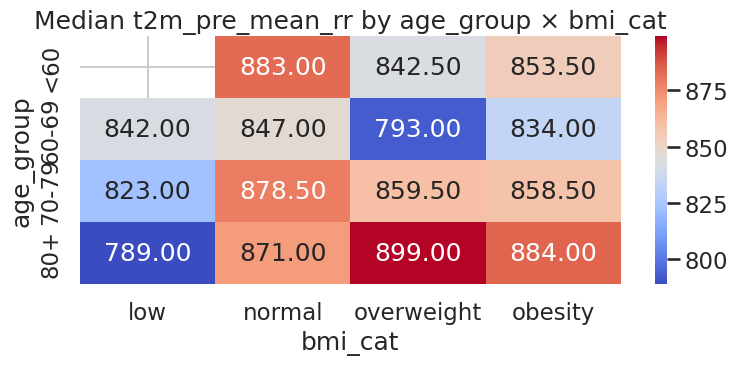

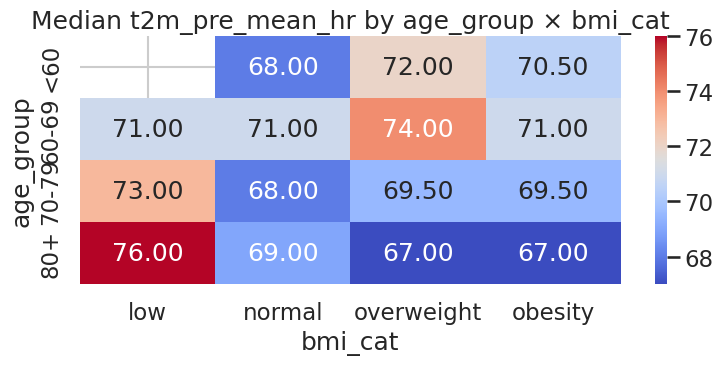

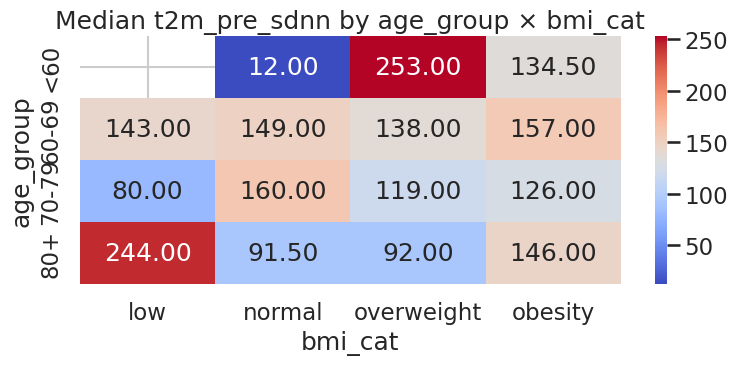

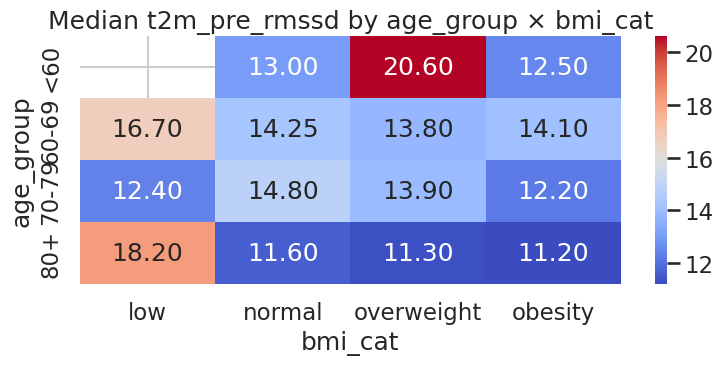

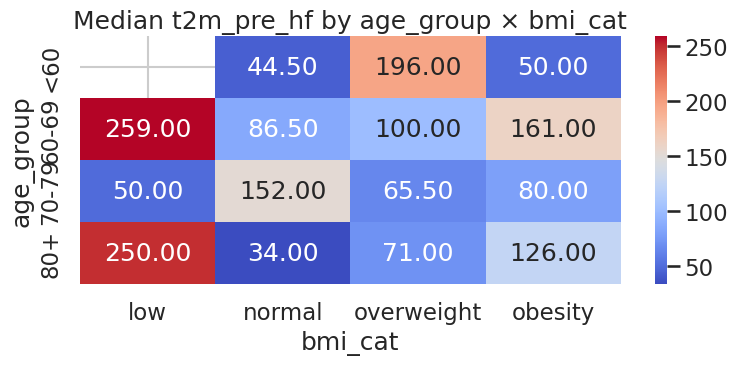

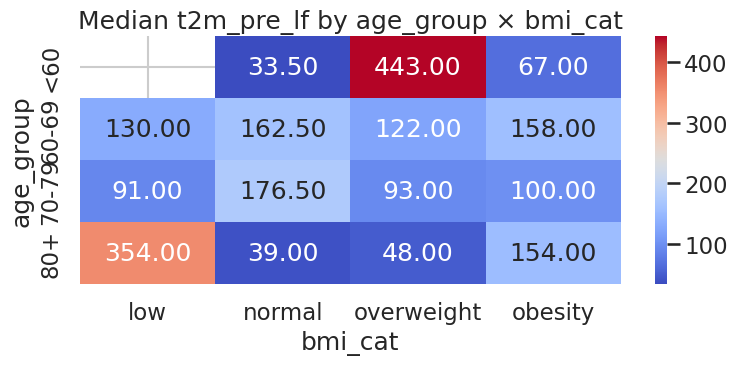

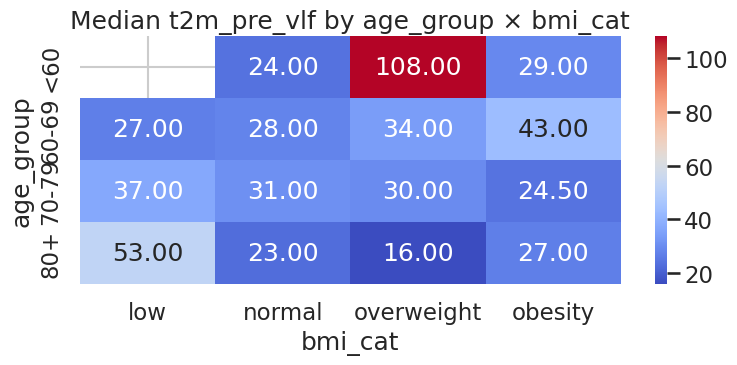

In [56]:
if all(c in df.columns for c in ["age_group", "bmi_cat"]):
    for hrv in existing_hrv_cols:
        tab = df.pivot_table(
            index="age_group",
            columns="bmi_cat",
            values=hrv,
            aggfunc="median"
        )

        plt.figure(figsize=(8, 4))
        sns.heatmap(tab, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title(f"Median {hrv} by age_group × bmi_cat")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"heatmap_{hrv}_age_group_bmi_cat.png", dpi=300)
        plt.show()

In [63]:
if not binary_results_df.empty:
    top_binary = (
        binary_results_df
        .sort_values(["significant_fdr", "p_adj_fdr", "cliffs_delta"], ascending=[False, True, False])
        .head(30)
    )
top_binary

,grouping_variable,value_variable,group_a,group_b,n_a,n_b,median_a,median_b,u_stat,p_value,cliffs_delta,cliffs_magnitude,rank_biserial,p_adj_fdr,significant_fdr
2,sex,t2m_pre_sdnn,1,2,360,159,154.0,72.00,40023.5,4.472665e-13,0.398445,medium,-0.398445,3.130865e-12,True
6,sex,t2m_pre_vlf,1,2,366,164,35.0,25.00,36530.5,6.335911e-05,0.217196,small,-0.217196,2.217569e-04,True
3,sex,t2m_pre_rmssd,1,2,362,160,14.0,12.50,33108.5,9.032589e-03,0.143249,negligible,-0.143249,1.746491e-02,True
5,sex,t2m_pre_lf,1,2,366,164,129.0,98.50,34211.5,9.979947e-03,0.139927,negligible,-0.139927,1.746491e-02,True
4,sex,t2m_pre_hf,1,2,366,164,111.0,76.00,32787.5,8.861350e-02,0.092480,negligible,-0.092480,1.240589e-01,False
7,bp_cat,t2m_pre_mean_rr,normal,high,369,161,857.0,834.00,32313.0,1.077183e-01,0.087815,negligible,-0.087815,3.770140e-01,False
8,bp_cat,t2m_pre_mean_hr,normal,high,368,161,69.5,72.00,27020.5,1.074122e-01,-0.087885,negligible,0.087885,3.770140e-01,False
9,bp_cat,t2m_pre_sdnn,normal,high,361,158,140.0,134.50,29169.0,6.795077e-01,0.022792,negligible,-0.022792,7.610749e-01,False
12,bp_cat,t2m_pre_lf,normal,high,369,161,122.0,111.00,30259.0,7.325830e-01,0.018667,negligible,-0.018667,7.610749e-01,False
13,bp_cat,t2m_pre_vlf,normal,high,369,161,31.0,31.00,30242.5,7.402264e-01,0.018112,negligible,-0.018112,7.610749e-01,False


In [64]:
if not kruskal_results_df.empty:
    top_multi = (
        kruskal_results_df
        .sort_values(["significant_fdr", "p_adj_fdr", "epsilon_squared"], ascending=[False, True, False])
        .head(30)
    )
top_multi

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr
5,age_group,t2m_pre_lf,530,4,19.444978,0.000221,0.031264,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.001548,True
4,age_group,t2m_pre_hf,530,4,11.828574,0.007994,0.016784,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.027979,True
1,age_group,t2m_pre_mean_hr,529,4,8.089549,0.044197,0.009694,"{'70-79': 261, '60-69': 218, '80+': 40, '<60':...",0.103126,False
6,age_group,t2m_pre_vlf,530,4,7.265084,0.063912,0.008109,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.111846,False
2,age_group,t2m_pre_sdnn,519,4,5.520829,0.137398,0.004895,"{'70-79': 256, '60-69': 214, '80+': 39, '<60':...",0.182391,False
0,age_group,t2m_pre_mean_rr,530,4,5.220645,0.156335,0.004222,"{'70-79': 261, '60-69': 219, '80+': 40, '<60':...",0.182391,False
3,age_group,t2m_pre_rmssd,522,4,4.480695,0.214019,0.002858,"{'70-79': 255, '60-69': 217, '80+': 40, '<60':...",0.214019,False
9,bmi_cat,t2m_pre_sdnn,519,4,7.261466,0.064015,0.008275,"{'normal': 153, 'overweight': 160, 'obesity': ...",0.448104,False
7,bmi_cat,t2m_pre_mean_rr,530,4,5.056120,0.167734,0.003909,"{'normal': 161, 'overweight': 162, 'obesity': ...",0.533046,False
11,bmi_cat,t2m_pre_hf,530,4,3.858375,0.277169,0.001632,"{'normal': 161, 'overweight': 162, 'obesity': ...",0.533046,False


In [65]:
if not double_kruskal_df.empty:
    top_double = (
        double_kruskal_df
        .sort_values(["significant_fdr", "p_adj_fdr", "epsilon_squared"], ascending=[False, True, False])
        .head(30)
    )
top_double

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr,combined_grouping
2,sex__age_group,t2m_pre_sdnn,517,7,62.178469,1.622659e-11,0.110154,"{'1 | 70-79': 163, '1 | 60-69': 160, '2 | 70-7...",1.135862e-10,True,sex__age_group
16,sex__bp_cat,t2m_pre_sdnn,519,4,52.711849,2.111923e-11,0.096528,"{'1 | normal': 257, '2 | normal': 104, '1 | hi...",1.478346e-10,True,sex__bp_cat
9,sex__bmi_cat,t2m_pre_sdnn,519,8,61.322907,8.212414e-11,0.106307,"{'1 | normal': 111, '2 | overweight': 57, '1 |...",5.748690e-10,True,sex__bmi_cat
26,age_group__bmi_cat,t2m_pre_lf,525,12,41.579853,1.914575e-05,0.059610,"{'70-79 | normal': 76, '60-69 | normal': 62, '...",1.340203e-04,True,age_group__bmi_cat
6,sex__age_group,t2m_pre_vlf,528,7,24.585871,4.072946e-04,0.035673,"{'1 | 70-79': 167, '1 | 60-69': 162, '2 | 70-7...",1.173355e-03,True,sex__age_group
5,sex__age_group,t2m_pre_lf,528,7,24.089311,5.028663e-04,0.034720,"{'1 | 70-79': 167, '1 | 60-69': 162, '2 | 70-7...",1.173355e-03,True,sex__age_group
20,sex__bp_cat,t2m_pre_vlf,530,4,16.227945,1.018256e-03,0.025148,"{'1 | normal': 261, '2 | normal': 108, '1 | hi...",3.563895e-03,True,sex__bp_cat
13,sex__bmi_cat,t2m_pre_vlf,530,8,22.617240,1.986807e-03,0.029918,"{'1 | normal': 114, '2 | overweight': 57, '1 |...",6.953825e-03,True,sex__bmi_cat
25,age_group__bmi_cat,t2m_pre_hf,525,12,28.749194,2.482396e-03,0.034599,"{'70-79 | normal': 76, '60-69 | normal': 62, '...",8.688387e-03,True,age_group__bmi_cat
33,age_group__bp_cat,t2m_pre_lf,530,7,21.689971,1.377863e-03,0.030000,"{'70-79 | normal': 180, '60-69 | normal': 153,...",9.645044e-03,True,age_group__bp_cat


In [66]:
if not triple_kruskal_df.empty:
    top_triple = (
        triple_kruskal_df
        .sort_values(["significant_fdr", "p_adj_fdr", "epsilon_squared"], ascending=[False, True, False])
        .head(30)
    )
top_triple

,grouping_variable,value_variable,n_total,n_groups,h_stat,p_value,epsilon_squared,group_sizes,p_adj_fdr,significant_fdr,combined_grouping
9,sex__age_group__bp_cat,t2m_pre_sdnn,507,11,56.979451,1.344828e-08,0.094717,"{'1 | 70-79 | normal': 116, '1 | 60-69 | norma...",9.413797e-08,True,sex__age_group__bp_cat
2,sex__age_group__bmi_cat,t2m_pre_sdnn,483,15,63.596058,2.720181e-08,0.105974,"{'1 | 70-79 | normal': 47, '1 | 60-69 | normal...",1.904127e-07,True,sex__age_group__bmi_cat
16,sex__bmi_cat__bp_cat,t2m_pre_sdnn,509,13,55.605748,1.409142e-07,0.087915,"{'1 | normal | normal': 82, '2 | overweight | ...",9.863993e-07,True,sex__bmi_cat__bp_cat
5,sex__age_group__bmi_cat,t2m_pre_lf,493,15,40.238173,2.341896e-04,0.054892,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",8.196635e-04,True,sex__age_group__bmi_cat
6,sex__age_group__bmi_cat,t2m_pre_vlf,493,15,35.515656,1.232494e-03,0.045012,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",2.875820e-03,True,sex__age_group__bmi_cat
13,sex__age_group__bp_cat,t2m_pre_vlf,517,11,26.841309,2.759165e-03,0.033283,"{'1 | 70-79 | normal': 119, '1 | 60-69 | norma...",9.657077e-03,True,sex__age_group__bp_cat
20,sex__bmi_cat__bp_cat,t2m_pre_vlf,520,13,28.617463,4.488852e-03,0.032776,"{'1 | normal | normal': 85, '2 | overweight | ...",1.571098e-02,True,sex__bmi_cat__bp_cat
12,sex__age_group__bp_cat,t2m_pre_lf,517,11,21.715358,1.662219e-02,0.023153,"{'1 | 70-79 | normal': 119, '1 | 60-69 | norma...",3.878511e-02,True,sex__age_group__bp_cat
26,age_group__bmi_cat__bp_cat,t2m_pre_lf,492,15,30.859388,5.800234e-03,0.035345,"{'70-79 | normal | normal': 57, '60-69 | norma...",4.060164e-02,True,age_group__bmi_cat__bp_cat
4,sex__age_group__bmi_cat,t2m_pre_hf,493,15,24.961358,3.495079e-02,0.022932,"{'1 | 70-79 | normal': 50, '1 | 60-69 | normal...",6.116389e-02,False,sex__age_group__bmi_cat


In [67]:
global_tables = []

if not binary_results_df.empty:
    tmp = binary_results_df.copy()
    tmp["analysis_level"] = "single_binary"
    tmp["global_effect"] = np.nan
    global_tables.append(tmp[[
        "analysis_level", "grouping_variable", "value_variable",
        "p_value", "p_adj_fdr", "significant_fdr", "global_effect"
    ]])

if not kruskal_results_df.empty:
    tmp = kruskal_results_df.copy()
    tmp["analysis_level"] = "single_multigroup"
    tmp["global_effect"] = tmp["epsilon_squared"]
    global_tables.append(tmp[[
        "analysis_level", "grouping_variable", "value_variable",
        "p_value", "p_adj_fdr", "significant_fdr", "global_effect"
    ]])

if not double_kruskal_df.empty:
    tmp = double_kruskal_df.copy()
    tmp["analysis_level"] = "double_combination"
    tmp["grouping_variable"] = tmp["combined_grouping"]
    tmp["global_effect"] = tmp["epsilon_squared"]
    global_tables.append(tmp[[
        "analysis_level", "grouping_variable", "value_variable",
        "p_value", "p_adj_fdr", "significant_fdr", "global_effect"
    ]])

if not triple_kruskal_df.empty:
    tmp = triple_kruskal_df.copy()
    tmp["analysis_level"] = "triple_combination"
    tmp["grouping_variable"] = tmp["combined_grouping"]
    tmp["global_effect"] = tmp["epsilon_squared"]
    global_tables.append(tmp[[
        "analysis_level", "grouping_variable", "value_variable",
        "p_value", "p_adj_fdr", "significant_fdr", "global_effect"
    ]])

global_results_df = pd.concat(global_tables, ignore_index=True) if global_tables else pd.DataFrame()
global_results_df.head()

,analysis_level,grouping_variable,value_variable,p_value,p_adj_fdr,significant_fdr,global_effect
0,single_binary,sex,t2m_pre_mean_rr,7.723418e-01,9.010655e-01,False,NaN
1,single_binary,sex,t2m_pre_mean_hr,9.194842e-01,9.194842e-01,False,NaN
2,single_binary,sex,t2m_pre_sdnn,4.472665e-13,3.130865e-12,True,NaN
3,single_binary,sex,t2m_pre_rmssd,9.032589e-03,1.746491e-02,True,NaN
4,single_binary,sex,t2m_pre_hf,8.861350e-02,1.240589e-01,False,NaN


In [68]:
if not global_results_df.empty:
    save_table(global_results_df, "global_nonparametric_summary.csv")

In [69]:
summary_dict = {
    "n_binary_tests": 0 if binary_results_df.empty else int(len(binary_results_df)),
    "n_binary_significant_fdr": 0 if binary_results_df.empty else int(binary_results_df["significant_fdr"].sum()),
    "n_multigroup_tests": 0 if kruskal_results_df.empty else int(len(kruskal_results_df)),
    "n_multigroup_significant_fdr": 0 if kruskal_results_df.empty else int(kruskal_results_df["significant_fdr"].sum()),
    "n_double_tests": 0 if double_kruskal_df.empty else int(len(double_kruskal_df)),
    "n_double_significant_fdr": 0 if double_kruskal_df.empty else int(double_kruskal_df["significant_fdr"].sum()),
    "n_triple_tests": 0 if triple_kruskal_df.empty else int(len(triple_kruskal_df)),
    "n_triple_significant_fdr": 0 if triple_kruskal_df.empty else int(triple_kruskal_df["significant_fdr"].sum()),
}

pd.Series(summary_dict, name="value")

n_binary_tests                  14
n_binary_significant_fdr         4
n_multigroup_tests              14
n_multigroup_significant_fdr     2
n_double_tests                  42
n_double_significant_fdr        13
n_triple_tests                  28
n_triple_significant_fdr         9
Name: value, dtype: int64